# RoBERTa - BANKING77 Intent Classification

This project fine-tunes the pretrained `roberta-base` model for 77-class intent classification on the BANKING77 dataset. The workflow uses the provided training and test splits, creates a stratified validation split from training data, selects the best checkpoint using validation macro F1, and evaluates the final model with class-level, confusion, confidence, and error analysis.

## 1. Import Required Libraries

Load the libraries needed for dataset loading, tokenization, RoBERTa fine-tuning, evaluation, visualization, and reproducibility.

In [1]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset, Dataset
from transformers import (
    RobertaTokenizerFast,
    RobertaForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PyTorch Version: 2.11.0+cu128
CUDA Available: True
GPU: Tesla T4


## 2. Load the BANKING77 Dataset

Load the dataset and inspect its splits and 77 intent labels.

In [2]:
from datasets import Dataset, DatasetDict

train_url = (
    "https://raw.githubusercontent.com/"
    "PolyAI-LDN/task-specific-datasets/"
    "master/banking_data/train.csv"
)

test_url = (
    "https://raw.githubusercontent.com/"
    "PolyAI-LDN/task-specific-datasets/"
    "master/banking_data/test.csv"
)

train_df = pd.read_csv(
    train_url
)

test_df = pd.read_csv(
    test_url
)

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

print("\nTrain Columns:")
print(train_df.columns.tolist())

print("\nTest Columns:")
print(test_df.columns.tolist())

print("\nFirst Training Example:")
print(train_df.head(1))

# The CSVs contain the banking query and its intent label.
# Convert the text labels into a stable integer mapping.
class_names = sorted(
    train_df["category"].unique()
)

label_to_id = {
    label: index
    for index, label in enumerate(class_names)
}

id_to_label = {
    index: label
    for label, index in label_to_id.items()
}

train_df["label"] = train_df["category"].map(
    label_to_id
)

test_df["label"] = test_df["category"].map(
    label_to_id
)

train_df = train_df[
    ["text", "label"]
].copy()

test_df = test_df[
    ["text", "label"]
].copy()

dataset = DatasetDict({
    "train": Dataset.from_pandas(
        train_df,
        preserve_index=False
    ),
    "test": Dataset.from_pandas(
        test_df,
        preserve_index=False
    )
})

print("\nDataset:")
print(dataset)

print(
    "\nNumber of Intent Classes:",
    len(class_names)
)

print("\nIntent Classes:")
for index, class_name in enumerate(class_names):
    print(
        f"{index:2d}: {class_name}"
    )

Train Shape: (10003, 2)
Test Shape: (3080, 2)

Train Columns:
['text', 'category']

Test Columns:
['text', 'category']

First Training Example:
                             text      category
0  I am still waiting on my card?  card_arrival

Dataset:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})

Number of Intent Classes: 77

Intent Classes:
 0: Refund_not_showing_up
 1: activate_my_card
 2: age_limit
 3: apple_pay_or_google_pay
 4: atm_support
 5: automatic_top_up
 6: balance_not_updated_after_bank_transfer
 7: balance_not_updated_after_cheque_or_cash_deposit
 8: beneficiary_not_allowed
 9: cancel_transfer
10: card_about_to_expire
11: card_acceptance
12: card_arrival
13: card_delivery_estimate
14: card_linking
15: card_not_working
16: card_payment_fee_charged
17: card_payment_not_recognised
18: card_payment_wrong_exchange_rate
19: card_swall

## 3. Create Stratified Train and Validation Splits

Keep the official test split untouched and create a stratified validation set from training data.

In [3]:
train_texts = np.array(
    dataset["train"]["text"],
    dtype=object
)

train_labels = np.array(
    dataset["train"]["label"],
    dtype=np.int64
)

test_texts = np.array(
    dataset["test"]["text"],
    dtype=object
)

test_labels = np.array(
    dataset["test"]["label"],
    dtype=np.int64
)

train_texts, val_texts, train_labels, val_labels = (
    train_test_split(
        train_texts,
        train_labels,
        test_size=0.10,
        random_state=SEED,
        stratify=train_labels
    )
)

print("Training Samples:", len(train_texts))
print("Validation Samples:", len(val_texts))
print("Test Samples:", len(test_texts))

print(
    "\nTraining Distribution:",
    np.bincount(
        train_labels,
        minlength=len(class_names)
    )
)

print(
    "\nValidation Distribution:",
    np.bincount(
        val_labels,
        minlength=len(class_names)
    )
)

print(
    "\nTest Distribution:",
    np.bincount(
        test_labels,
        minlength=len(class_names)
    )
)

Training Samples: 9002
Validation Samples: 1001
Test Samples: 3080

Training Distribution: [146 143  99 113  78 114 154 163 140 141 116  53 138 101 125 101 168 151
 150  55 159 144 110  77  32 116 138 156 120 164 109 109 109 101 106 149
 123 113  87  95 116  88  74 109 108  95 143 129 134 133 104  86 152 145
 116  97 100 103 103 130  87 131  93 157 155 102 154 115  92  94 102 113
  37 121 109 162 147]

Validation Distribution: [16 16 11 13  9 13 17 18 16 16 13  6 15 11 14 11 19 17 17  6 18 16 12  9
  3 13 15 17 13 18 12 12 12 11 12 17 14 13 10 11 13 10  8 12 12 10 16 14
 15 15 11  9 17 16 13 11 11 11 11 15 10 15 10 18 17 11 17 13 10 10 11 13
  4 14 12 18 16]

Test Distribution: [40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40
 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40
 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40 40
 40 40 40 40 40]


## 4. Explore the Dataset

Inspect the intent distribution and representative banking queries.

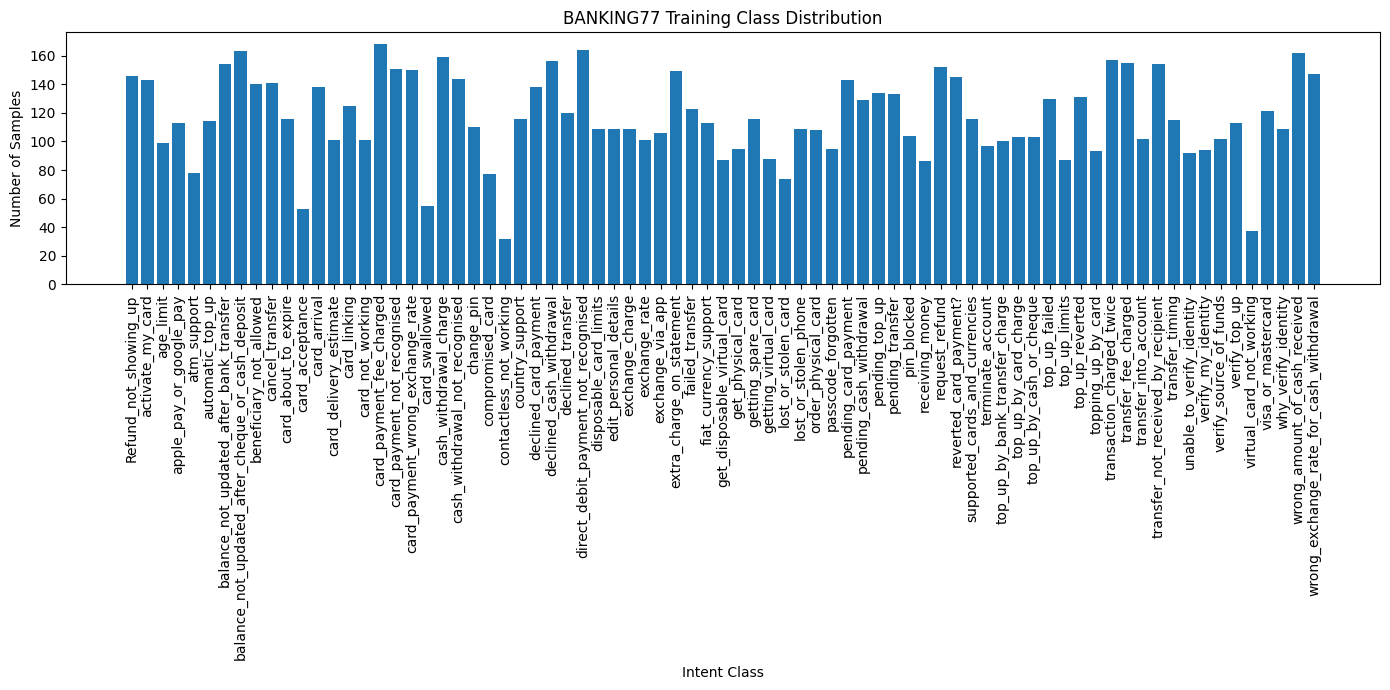

Intent: Refund_not_showing_up
- When will my returned transaction show up on my account?
- How do I find the refund on my statement?

Intent: activate_my_card
- I want to activate the card.
- how long should i wait ti activate my card

Intent: age_limit
- If I want my son to have his own account is that possible?
- What age do you have to be to open an account?

Intent: apple_pay_or_google_pay
- How do i top up my google pay?
- Am I able to top up with Apple Pay?

Intent: atm_support
- How far is the closest ATM from me?
- What's the closest place to withdraw money?

Intent: automatic_top_up
- If I am running low on credit can I auto top up?
- What is the maximum times I can auto top-up?

Intent: balance_not_updated_after_bank_transfer
- Can you tell me why the transfer isn't showing up on my account?
- I haven't yet received money that I transferred

Intent: balance_not_updated_after_cheque_or_cash_deposit
- Hi,  My money has not been credited to my account for which i have sent you c

In [4]:
train_counts = np.bincount(train_labels, minlength=len(class_names))

plt.figure(figsize=(14, 7))
plt.bar(range(len(class_names)), train_counts)
plt.xlabel("Intent Class")
plt.ylabel("Number of Samples")
plt.title("BANKING77 Training Class Distribution")
plt.xticks(range(len(class_names)), class_names, rotation=90)
plt.tight_layout()
plt.show()

for class_id, class_name in enumerate(class_names):
    indices = np.where(train_labels == class_id)[0]
    print("=" * 100)
    print("Intent:", class_name)
    for index in indices[:2]:
        print("-", train_texts[index])
    print()

## 5. Load the RoBERTa Tokenizer

Use the pretrained RoBERTa tokenizer.

In [5]:
model_name = "roberta-base"
max_length = 128

tokenizer = RobertaTokenizerFast.from_pretrained(model_name)

print("Model:", model_name)
print("Vocabulary Size:", tokenizer.vocab_size)
print("Maximum Sequence Length:", max_length)

sample = tokenizer(train_texts[0], truncation=True, padding="max_length", max_length=max_length)
print("Sample Token Count:", len(sample["input_ids"]))

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Model: roberta-base
Vocabulary Size: 50265
Maximum Sequence Length: 128
Sample Token Count: 128


## 6. Tokenize the Dataset

Tokenize training, validation, and test queries and prepare them for Trainer.

In [6]:
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=max_length
    )

train_dataset = Dataset.from_dict({
    "text": train_texts.tolist(),
    "label": train_labels.tolist()
})
val_dataset = Dataset.from_dict({
    "text": val_texts.tolist(),
    "label": val_labels.tolist()
})
test_dataset = Dataset.from_dict({
    "text": test_texts.tolist(),
    "label": test_labels.tolist()
})

train_dataset = train_dataset.map(tokenize_batch, batched=True)
val_dataset = val_dataset.map(tokenize_batch, batched=True)
test_dataset = test_dataset.map(tokenize_batch, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
val_dataset = val_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(train_dataset)
print(val_dataset)
print(test_dataset)

Map:   0%|          | 0/9002 [00:00<?, ? examples/s]

Map:   0%|          | 0/1001 [00:00<?, ? examples/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 9002
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 1001
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 3080
})


## 7. Build the RoBERTa Intent Classifier

Load pretrained RoBERTa with a 77-class classification head.

In [7]:
model = RobertaForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(class_names),
    id2label={i: name for i, name in enumerate(class_names)},
    label2id={name: i for i, name in enumerate(class_names)}
)

print("Model:", model_name)
print("Number of Labels:", model.config.num_labels)
print("Trainable Parameters:", f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: roberta-base
Number of Labels: 77
Trainable Parameters: 124,704,845


## 8. Define Evaluation Metrics

Track accuracy, macro precision, recall, macro F1, and weighted F1.

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        labels, predictions, average="macro", zero_division=0
    )
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        labels, predictions, average="weighted", zero_division=0
    )

    return {
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1
    }

## 9. Configure Fine-Tuning

Use Hugging Face Trainer with a conservative RoBERTa fine-tuning setup and validation macro F1 as the checkpoint-selection metric.

In [9]:
batch_size = 32
learning_rate = 2e-5
num_epochs = 6

training_args = TrainingArguments(
    output_dir="./roberta_banking77_results",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    learning_rate=learning_rate,
    num_train_epochs=num_epochs,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_macro_f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
    data_seed=SEED,
    save_total_limit=2
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Batch Size:", batch_size)
print("Learning Rate:", learning_rate)
print("Maximum Epochs:", num_epochs)
print("Best Checkpoint Metric: Validation Macro F1")

Batch Size: 32
Learning Rate: 2e-05
Maximum Epochs: 6
Best Checkpoint Metric: Validation Macro F1


## 10. Fine-Tune RoBERTa

Train on the training split and evaluate on validation after each epoch.

In [10]:
train_result = trainer.train()

print("Training completed.")
print("Training Loss:", train_result.training_loss)
print("Best Checkpoint:", trainer.state.best_model_checkpoint)

if trainer.state.best_metric is not None:
    print(f"Best Validation Macro F1: {trainer.state.best_metric:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,4.072791,3.479023,0.162837,0.153632,0.154680,0.101682,0.168645,0.162837,0.107730
2,3.051548,2.449488,0.423576,0.419603,0.403051,0.355931,0.431307,0.423576,0.370881
3,2.311622,1.937462,0.572428,0.586916,0.545512,0.518076,0.600043,0.572428,0.538774
4,1.861628,1.600524,0.646354,0.665492,0.617086,0.608214,0.674491,0.646354,0.631834
5,1.600141,1.432858,0.692308,0.717464,0.669107,0.664504,0.719836,0.692308,0.682021
6,1.461245,1.374186,0.685315,0.698708,0.661524,0.656850,0.707045,0.685315,0.676477


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training completed.
Training Loss: 2.3931627747014903
Best Checkpoint: ./roberta_banking77_results/checkpoint-1410
Best Validation Macro F1: 0.6645


## 11. Training Curves

Visualize loss and validation performance.

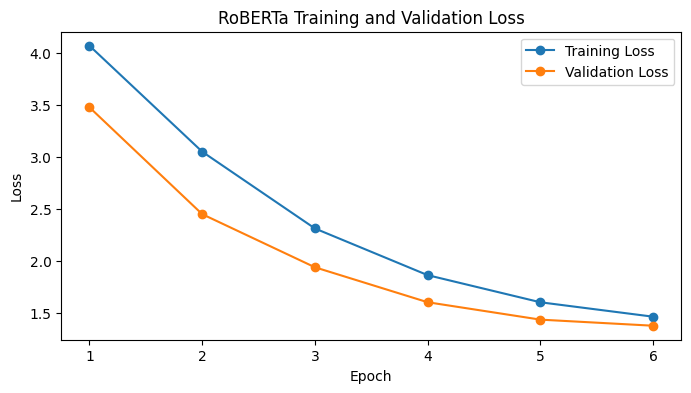

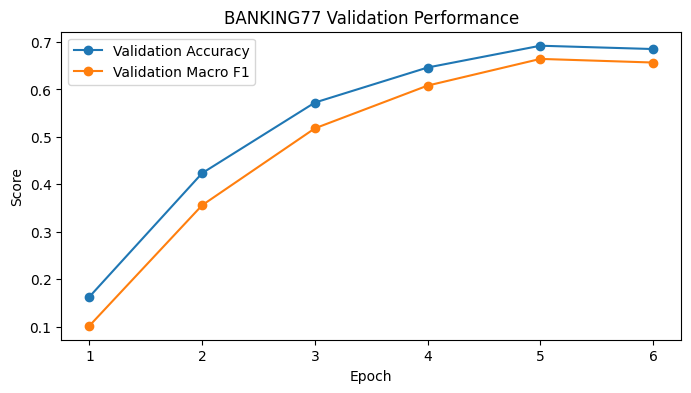

Best Epoch: 5
Best Validation Accuracy: 0.6923
Best Validation Macro F1: 0.6645


In [11]:
history = pd.DataFrame(trainer.state.log_history)
train_history = history[history["loss"].notna()].copy()
eval_history = history[history["eval_loss"].notna()].copy()

plt.figure(figsize=(8, 4))
plt.plot(train_history["epoch"], train_history["loss"], marker="o", label="Training Loss")
plt.plot(eval_history["epoch"], eval_history["eval_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RoBERTa Training and Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(eval_history["epoch"], eval_history["eval_accuracy"], marker="o", label="Validation Accuracy")
plt.plot(eval_history["epoch"], eval_history["eval_macro_f1"], marker="o", label="Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("BANKING77 Validation Performance")
plt.legend()
plt.show()

best_row = eval_history.loc[eval_history["eval_macro_f1"].idxmax()]
print("Best Epoch:", int(best_row["epoch"]))
print(f"Best Validation Accuracy: {best_row['eval_accuracy']:.4f}")
print(f"Best Validation Macro F1: {best_row['eval_macro_f1']:.4f}")

## 12. Final Test Evaluation

Evaluate the restored best checkpoint exactly once on the untouched test set.

In [12]:
test_output = trainer.predict(test_dataset)
test_predictions = np.argmax(test_output.predictions, axis=-1)
test_labels_final = np.array(test_output.label_ids)

test_accuracy = accuracy_score(test_labels_final, test_predictions)
test_macro_precision, test_macro_recall, test_macro_f1, _ = precision_recall_fscore_support(
    test_labels_final, test_predictions, average="macro", zero_division=0
)
test_weighted_precision, test_weighted_recall, test_weighted_f1, _ = precision_recall_fscore_support(
    test_labels_final, test_predictions, average="weighted", zero_division=0
)

print(f"Test Loss: {test_output.metrics.get('test_loss', float('nan')):.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Macro Precision: {test_macro_precision:.4f}")
print(f"Test Macro Recall: {test_macro_recall:.4f}")
print(f"Test Macro F1: {test_macro_f1:.4f}")
print(f"Test Weighted F1: {test_weighted_f1:.4f}")

Test Loss: 1.5044
Test Accuracy: 0.6607
Test Macro Precision: 0.6832
Test Macro Recall: 0.6607
Test Macro F1: 0.6381
Test Weighted F1: 0.6381


## 13. Classification Report and Confusion Matrix

Inspect 77-intent class-level performance and common confusion patterns.

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,recall,f1-score,support
Refund_not_showing_up,0.654545,0.900000,0.757895,40.000000
activate_my_card,0.553846,0.900000,0.685714,40.000000
age_limit,0.844444,0.950000,0.894118,40.000000
apple_pay_or_google_pay,0.930233,1.000000,0.963855,40.000000
atm_support,0.833333,0.750000,0.789474,40.000000
...,...,...,...,...
wrong_amount_of_cash_received,0.727273,0.600000,0.657534,40.000000
wrong_exchange_rate_for_cash_withdrawal,0.909091,0.500000,0.645161,40.000000
accuracy,0.660714,0.660714,0.660714,0.660714
macro avg,0.683197,0.660714,0.638093,3080.000000


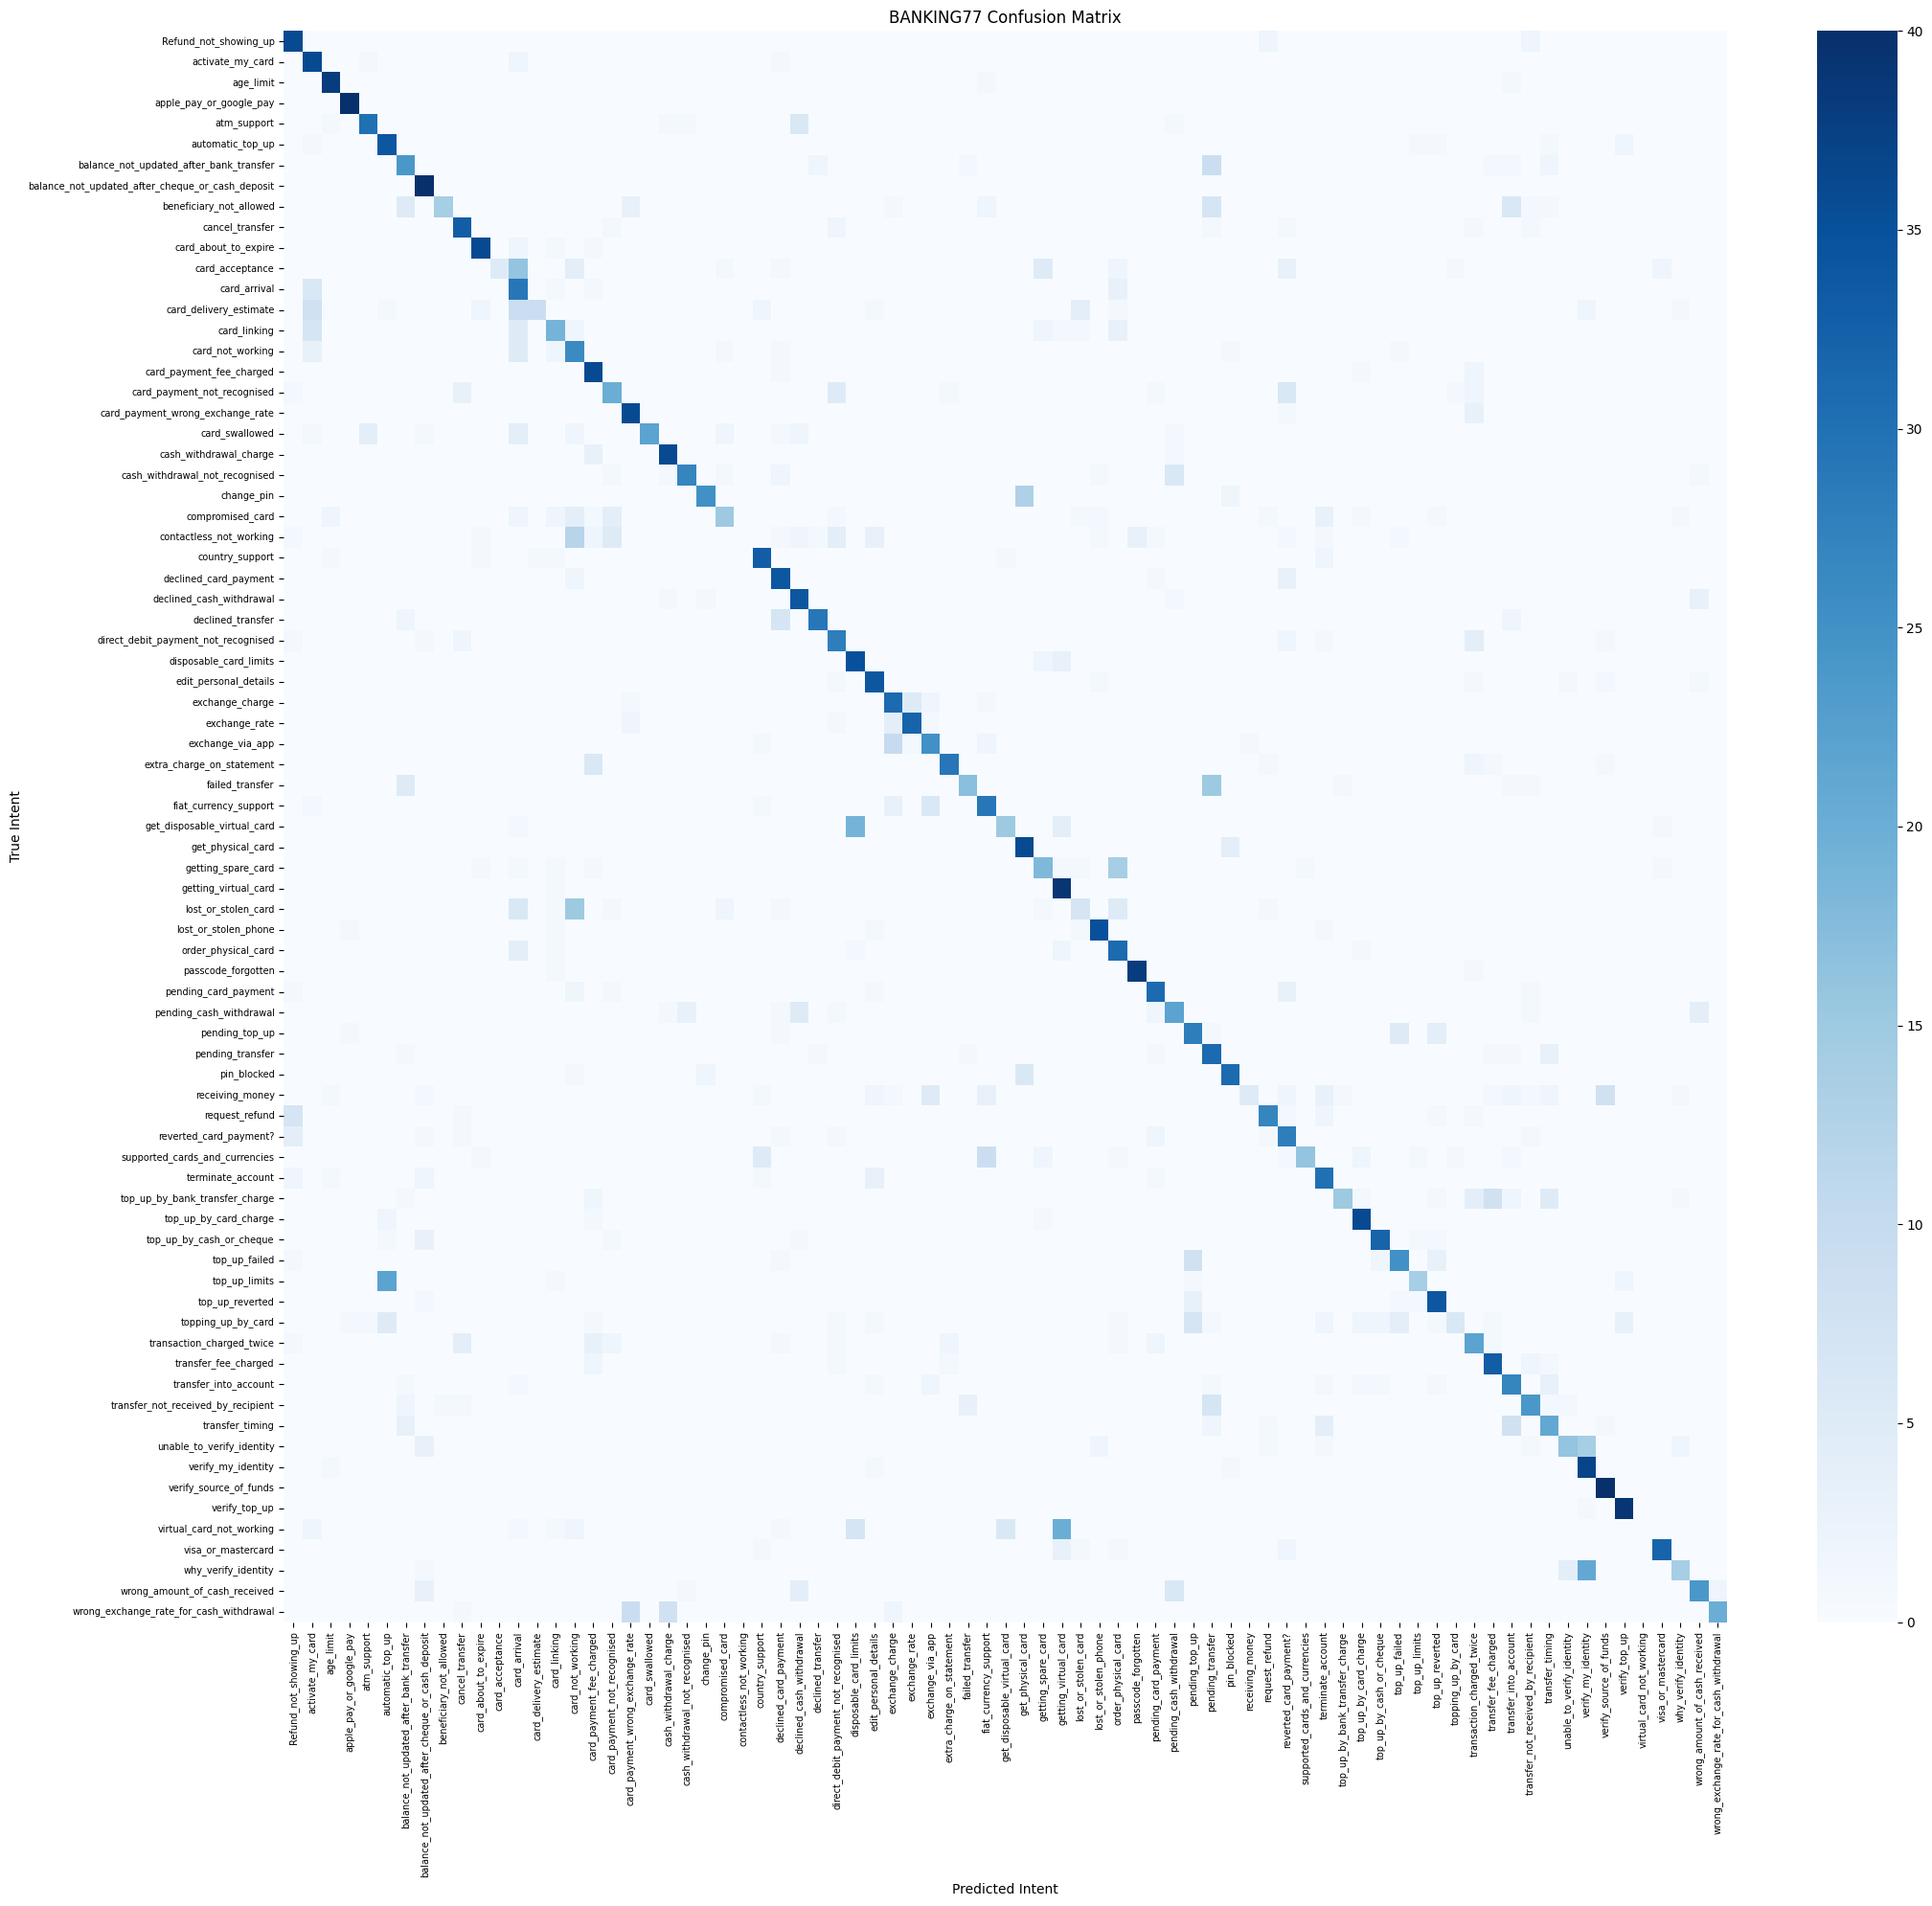

In [13]:
report = classification_report(
    test_labels_final,
    test_predictions,
    target_names=class_names,
    digits=4,
    output_dict=True
)
report_df = pd.DataFrame(report).transpose()
display(report_df)

cm = confusion_matrix(test_labels_final, test_predictions)

plt.figure(figsize=(22, 20))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True
)
plt.xlabel("Predicted Intent")
plt.ylabel("True Intent")
plt.title("BANKING77 Confusion Matrix")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

## 14. Per-Intent Performance Analysis

Rank the strongest and weakest intents by F1-score.

In [14]:
per_class_report = report_df.loc[
    class_names,
    ["precision", "recall", "f1-score", "support"]
].copy()

print("10 Lowest-F1 Intents")
display(per_class_report.sort_values("f1-score").head(10))

print("10 Highest-F1 Intents")
display(per_class_report.sort_values("f1-score", ascending=False).head(10))

10 Lowest-F1 Intents


,precision,recall,f1-score,support
contactless_not_working,0.000000,0.000,0.000000,40.0
virtual_card_not_working,0.000000,0.000,0.000000,40.0
receiving_money,0.833333,0.125,0.217391,40.0
card_acceptance,1.000000,0.125,0.222222,40.0
topping_up_by_card,0.666667,0.150,0.244898,40.0
lost_or_stolen_card,0.437500,0.175,0.250000,40.0
card_delivery_estimate,0.900000,0.225,0.360000,40.0
card_arrival,0.329545,0.725,0.453125,40.0
card_not_working,0.361111,0.650,0.464286,40.0
why_verify_identity,0.700000,0.350,0.466667,40.0


10 Highest-F1 Intents


,precision,recall,f1-score,support
apple_pay_or_google_pay,0.930233,1.000,0.963855,40.0
passcode_forgotten,0.926829,0.950,0.938272,40.0
verify_top_up,0.847826,0.975,0.906977,40.0
age_limit,0.844444,0.950,0.894118,40.0
card_about_to_expire,0.857143,0.900,0.878049,40.0
verify_source_of_funds,0.769231,1.000,0.869565,40.0
lost_or_stolen_phone,0.853659,0.875,0.864198,40.0
top_up_by_card_charge,0.800000,0.900,0.847059,40.0
visa_or_mastercard,0.888889,0.800,0.842105,40.0
top_up_by_cash_or_cheque,0.864865,0.800,0.831169,40.0


## 15. Confidence Analysis

Compare confidence for correct and incorrect predictions.

Mean Confidence - Correct: 0.4638
Mean Confidence - Incorrect: 0.2685


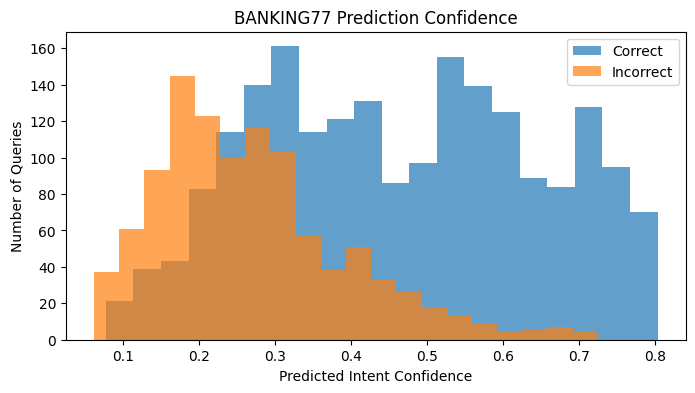

In [15]:
probabilities = torch.softmax(
    torch.tensor(test_output.predictions),
    dim=-1
).numpy()

predicted_confidence = probabilities[
    np.arange(len(test_predictions)),
    test_predictions
]

correct_mask = test_predictions == test_labels_final

print(f"Mean Confidence - Correct: {predicted_confidence[correct_mask].mean():.4f}")
if np.any(~correct_mask):
    print(f"Mean Confidence - Incorrect: {predicted_confidence[~correct_mask].mean():.4f}")

plt.figure(figsize=(8, 4))
plt.hist(predicted_confidence[correct_mask], bins=20, alpha=0.7, label="Correct")
if np.any(~correct_mask):
    plt.hist(predicted_confidence[~correct_mask], bins=20, alpha=0.7, label="Incorrect")
plt.xlabel("Predicted Intent Confidence")
plt.ylabel("Number of Queries")
plt.title("BANKING77 Prediction Confidence")
plt.legend()
plt.show()

## 16. Representative Error Analysis

Inspect representative misclassified queries and their strongest alternative intents.

In [16]:
misclassified_indices = np.where(
    test_predictions != test_labels_final
)[0]

print("Misclassified Test Queries:", len(misclassified_indices))

for index in misclassified_indices[:15]:
    row = probabilities[index]
    top_indices = np.argsort(row)[-3:][::-1]

    print("=" * 110)
    print("Query:", test_texts[index])
    print("True Intent:", class_names[test_labels_final[index]])
    print("Predicted Intent:", class_names[test_predictions[index]])
    print("Top Predictions:")

    for class_id in top_indices:
        print(f"  {class_names[class_id]}: {row[class_id]:.4f}")

Misclassified Test Queries: 1045
Query: I ordered a card but it has not arrived. Help please!
True Intent: card_arrival
Predicted Intent: order_physical_card
Top Predictions:
  order_physical_card: 0.1369
  getting_spare_card: 0.0816
  getting_virtual_card: 0.0781
Query: still waiting on that card
True Intent: card_arrival
Predicted Intent: card_linking
Top Predictions:
  card_linking: 0.2654
  activate_my_card: 0.2538
  card_arrival: 0.0819
Query: Is it normal to have to wait over a week for my new card?
True Intent: card_arrival
Predicted Intent: activate_my_card
Top Predictions:
  activate_my_card: 0.3438
  card_arrival: 0.2135
  card_linking: 0.0690
Query: still waiting on my new card
True Intent: card_arrival
Predicted Intent: activate_my_card
Top Predictions:
  activate_my_card: 0.3656
  card_arrival: 0.1817
  card_linking: 0.0921
Query: I've been waiting longer than expected for my card.
True Intent: card_arrival
Predicted Intent: card_payment_fee_charged
Top Predictions:
  card

## 17. Interactive Intent Prediction

Run custom banking queries through the fine-tuned classifier.

In [17]:
def predict_intent(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_length
    )

    device = next(model.parameters()).device
    inputs = {key: value.to(device) for key, value in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]
    predicted_class = int(np.argmax(probabilities))

    print("Query:", text)
    print("Predicted Intent:", class_names[predicted_class])
    print(f"Confidence: {probabilities[predicted_class]:.4f}")

    top_indices = np.argsort(probabilities)[-5:][::-1]
    print("
Top Intent Predictions:")
    for class_id in top_indices:
        print(f"{class_names[class_id]:<40}{probabilities[class_id]:.4f}")

for example in [
    "Where is my card?",
    "I do not recognize this cash withdrawal",
    "Why is my transfer still pending?",
    "I need to change my PIN"
]:
    predict_intent(example)
    print("=" * 90)

SyntaxError: unterminated string literal (detected at line 25) (4018585291.py, line 25)

## 18. Key Findings

Summarize the final metrics, strongest and weakest intents, confusion patterns, and practical implications.

## 19. Conclusion

Conclude the experiment using the final test results and error analysis.